In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

In [2]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=False, size=224)
val_dataset = DermaMNIST(split="val", download=False, size=224)
test_dataset = DermaMNIST(split="test", download=False, size=224)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7
Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [4]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label[0]) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


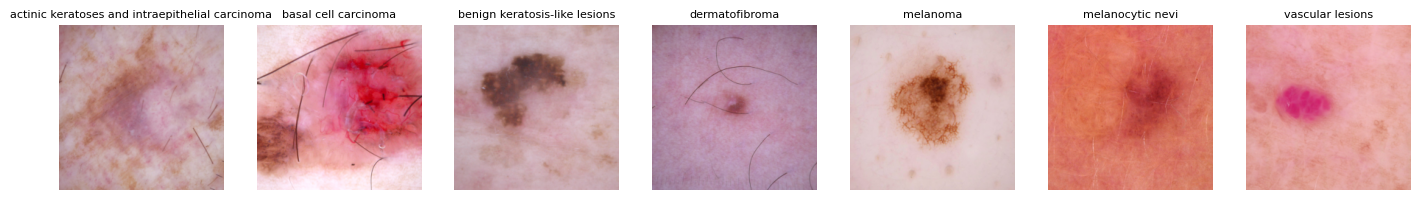

In [6]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label[0])
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [5]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma

In [8]:
img, label = train_dataset[0]
print(np.array(img).shape)
info["n_channels"]

(224, 224, 3)


3

In [9]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [10]:
train_dataset = DermaMNIST(
    split="train",
    transform=train_transform,   
    download=True,
    size=224
)

val_dataset = DermaMNIST(
    split="val",
    transform=test_transform,
    download=True,
    size=224
)

test_dataset = DermaMNIST(
    split="test",
    transform=test_transform,
    download=True,
    size=224
)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

n_classes = len(train_dataset.info["label"])

In [12]:
def get_resnet18():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

def get_resnet50():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def compute_auc(model, loader, split):
    model.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.append(labels.cpu())
            y_score.append(probs.cpu())

    y_true = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()

    evaluator = Evaluator("dermamnist", split)
    metrics = evaluator.evaluate(y_score)

    return metrics

In [13]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [14]:
resnet18 = get_resnet18()
resnet18 = train_model(resnet18, train_loader, val_loader, epochs=5)

test_acc_18 = evaluate(resnet18, test_loader)
print(f"ResNet18 Test Accuracy: {test_acc_18:.4f}")

val_auc_18 = compute_auc(resnet18, val_loader, split="val")
test_auc_18 = compute_auc(resnet18, test_loader, split="test")

print("ResNet18 Val Metrics:", val_auc_18)
print("ResNet18 Test Metrics:", test_auc_18)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 88.1183 | Val Acc: 0.7547
Epoch 2/5 | Loss: 72.8852 | Val Acc: 0.6989
Epoch 3/5 | Loss: 67.7623 | Val Acc: 0.7099
Epoch 4/5 | Loss: 65.0284 | Val Acc: 0.7657
Epoch 5/5 | Loss: 60.6718 | Val Acc: 0.7129
ResNet18 Test Accuracy: 0.6983
ResNet18 Val Metrics: Metrics(AUC=0.9207696653629152, ACC=0.7128614157527418)
ResNet18 Test Metrics: Metrics(AUC=0.9030265312673283, ACC=0.6982543640897756)


In [15]:
resnet50 = get_resnet50()
resnet50 = train_model(resnet50, train_loader, val_loader, epochs=5)

test_acc_50 = evaluate(resnet50, test_loader)
print(f"ResNet50 Test Accuracy: {test_acc_50:.4f}")

val_auc_50 = compute_auc(resnet50, val_loader, split="val")
test_auc_50 = compute_auc(resnet50, test_loader, split="test")

print("ResNet50 Val Metrics:", val_auc_50)
print("ResNet50 Test Metrics:", test_auc_50)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/diana/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████████████████████████████████| 97.8M/97.8M [00:02<00:00, 42.5MB/s]


Epoch 1/5 | Loss: 94.8603 | Val Acc: 0.7468
Epoch 2/5 | Loss: 82.8247 | Val Acc: 0.7378
Epoch 3/5 | Loss: 76.7858 | Val Acc: 0.6780
Epoch 4/5 | Loss: 71.9849 | Val Acc: 0.7627
Epoch 5/5 | Loss: 71.3322 | Val Acc: 0.7438
ResNet50 Test Accuracy: 0.7352
ResNet50 Val Metrics: Metrics(AUC=0.9336992970712205, ACC=0.7437686939182453)
ResNet50 Test Metrics: Metrics(AUC=0.9176276962973074, ACC=0.7351620947630922)
